# Homework 3
File contains code used to answer one of the problems in Homework 3 completed for MATH 5770 taught by Bao Wang at The University of Utah in Fall 2026.

## Problem 3.2
This question asks us to generate some random points based on a given function and then plot a least squares regression solution to it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
SEED = np.random.seed(314)
x = np.linspace(0,1,30)
y = 2*x**2 - 3*x + 1 + 0.05*np.random.normal(size=len(x))

coeff = np.polyfit(x, y, deg=2)

print(f"{coeff[0]:.2f}x^2 + {coeff[1]:.2f}x + {coeff[2]:.2f}")

1.95x^2 + -2.95x + 1.00


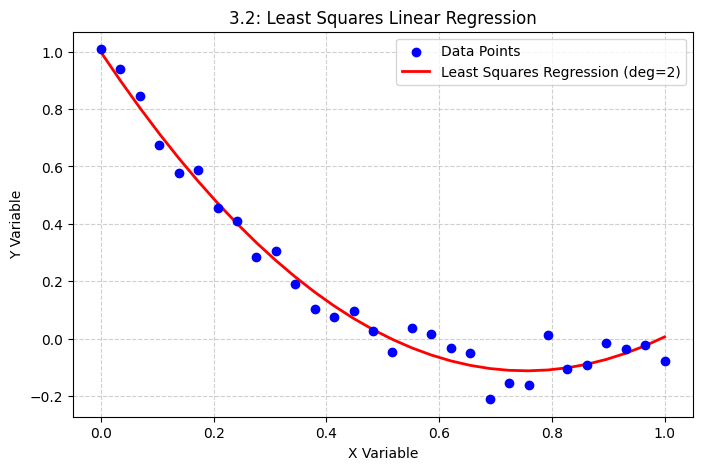

In [10]:
y_pred = coeff[0] * x**2 + coeff[1]*x + coeff[2]

plt.figure(figsize=(8, 5))

# Scatter plot of the original data points
plt.scatter(x, y, color="blue", label="Data Points", zorder=5)

# Line plot of the regression line
plt.plot(
    x, y_pred, color="red", linewidth=2, label=f"Least Squares Regression (deg=2)"
)

# Customize the chart layout
plt.title("3.2: Least Squares Linear Regression")
plt.xlabel("X Variable")
plt.ylabel("Y Variable")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Display the plot
plt.show()

## Problem 4.3
Consider the minimization problem $\text{min} \{x^TAx:x\in\mathbb{R}^5\}$ where $A$ is the 5 $\times$ 5 Hilbert matrix defined by:
$$A_{i,j}=\frac{1}{i+j-1}, i,j = 1,2,3,4,5$$
Run the following methods and compare the number of iterations required by each of the methods when the inital vector is $x_0 = (1,2,3,4,5)^T$ to obtain a solution with $\|\nabla f(x)\|\leq 10^{-4}$.

### First Method
Gradient method with backtracking step size rule and parameters $\alpha=0.5, \beta = 0.5, s=1$.

In [ ]:
from scipy.linalg import hilbert

A = hilbert(5)

[[1.         0.5        0.33333333 0.25       0.2       ]
 [0.5        0.33333333 0.25       0.2        0.16666667]
 [0.33333333 0.25       0.2        0.16666667 0.14285714]
 [0.25       0.2        0.16666667 0.14285714 0.125     ]
 [0.2        0.16666667 0.14285714 0.125      0.11111111]]


In [18]:
def f(x):
    return x.T @ A @ x

def grad_f(x):
    return 2 * (A @ x)

tol = 10e-4
alpha = 0.5
beta = 0.5
s = 1

x0 = np.array([1.0, 2.0, 3.0, 4.0, 5.0])

x = x0.copy()
iterations = 0
max_iter = 10000  # Safety limit

print(f"Initial x: {x}")
print(f"Initial f(x): {f(x):.6f}\n")

while iterations < max_iter:
    g = grad_f(x)
    g_norm = np.linalg.norm(g)
    
    if g_norm < tol:
        break
        
    # Descent direction (negative gradient)
    d = -g
    
    # Backtracking line search to find step size t
    t = s
    while f(x + t * d) > f(x) + alpha * t * (g.T @ d):
        t *= beta
        
    # Update x
    x = x + t * d
    iterations += 1

print(f"Optimization completed in {iterations} iterations.")
print(f"Optimal x: {x}")
print(f"Optimal f(x): {f(x):.10e}")
print(f"Gradient norm: {np.linalg.norm(grad_f(x)):.10e}")

Initial x: [1. 2. 3. 4. 5.]
Initial f(x): 40.015873

Optimization completed in 256 iterations.
Optimal x: [-0.02015248  0.22241378 -0.35218487 -0.20854722  0.39325981]
Optimal f(x): 1.2398681977e-04
Gradient norm: 9.1069296003e-04
